<a href="https://colab.research.google.com/github/dldustj0715/machine_learning/blob/main/week04/%EA%B8%B0%EA%B3%84%ED%95%99%EC%8A%B5_0928_car_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# ============================================================
# Car Evaluation Dataset
# Logistic Regression을 이용한 Class Classification
# ============================================================

# 1. 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# ============================================================
# 2. 데이터 불러오기
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/car.data', header=None)

# column 이름 설정
df.columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

print("===== 데이터 확인 =====")
print(df.head())

print("\n===== 데이터 크기 =====")
print(df.shape)

print("\n===== Class 분포 =====")
print(df['class'].value_counts())


===== 데이터 확인 =====
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc

===== 데이터 크기 =====
(1728, 7)

===== Class 분포 =====
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [33]:


# ============================================================
# 3. Label Encoding
# ============================================================

# 각 column별 LabelEncoder 저장
label_encoders = {}

for column in df.columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])


print("\n===== Label Encoding 결과 =====")
print(df.head())


# class가 어떤 숫자로 변환되었는지 확인
print("\n===== Class Label =====")

class_encoder = label_encoders['class']

for i, class_name in enumerate(class_encoder.classes_):
    print(class_name, "->", i)





===== Label Encoding 결과 =====
   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2

===== Class Label =====
acc -> 0
good -> 1
unacc -> 2
vgood -> 3


In [34]:
# ============================================================
# 4. X와 y 분리
# ============================================================

X = df.drop('class', axis=1)
y = df['class']

print("\n===== X =====")
print(X.head())

print("\n===== y =====")
print(y.head())





===== X =====
   buying  maint  doors  persons  lug_boot  safety
0       3      3      0        0         2       1
1       3      3      0        0         2       2
2       3      3      0        0         2       0
3       3      3      0        0         1       1
4       3      3      0        0         1       2

===== y =====
0    2
1    2
2    2
3    2
4    2
Name: class, dtype: int64


In [35]:
# ============================================================
# 5. Train / Test 데이터 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== Train / Test 크기 =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)




===== Train / Test 크기 =====
X_train: (1382, 6)
X_test : (346, 6)
y_train: (1382,)
y_test : (346,)


In [36]:

# ============================================================
# 6. Logistic Regression 모델 생성 및 학습
# ============================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)




LogisticRegression(max_iter=1000)

In [37]:
# ============================================================
# 7. Test 데이터 예측
# ============================================================

y_pred = model.predict(X_test)

print("\n===== 예측 결과 일부 =====")
print(y_pred[:20])


# 숫자로 된 예측 결과를 원래 class 이름으로 변환
y_pred_label = class_encoder.inverse_transform(y_pred)

print("\n===== 실제 Class 이름으로 변환 =====")
print(y_pred_label[:20])




===== 예측 결과 일부 =====
[2 2 2 2 3 2 2 2 2 2 0 2 2 2 2 2 0 2 2 2]

===== 실제 Class 이름으로 변환 =====
['unacc' 'unacc' 'unacc' 'unacc' 'vgood' 'unacc' 'unacc' 'unacc' 'unacc'
 'unacc' 'acc' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc' 'acc' 'unacc'
 'unacc' 'unacc']


In [38]:

# ============================================================
# 8. Accuracy 평가
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===== Accuracy =====")
print("Accuracy:", accuracy)




===== Accuracy =====
Accuracy: 0.6907514450867052


In [39]:

# ============================================================
# 9. Classification Report
# ============================================================

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_encoder.classes_
    )
)




===== Classification Report =====
              precision    recall  f1-score   support

         acc       0.29      0.08      0.12        77
        good       0.00      0.00      0.00        14
       unacc       0.73      0.95      0.83       242
       vgood       0.20      0.15      0.17        13

    accuracy                           0.69       346
   macro avg       0.30      0.30      0.28       346
weighted avg       0.58      0.69      0.61       346



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== Confusion Matrix =====
[[  6   0  63   8]
 [  1   0  13   0]
 [ 11   0 231   0]
 [  3   0   8   2]]


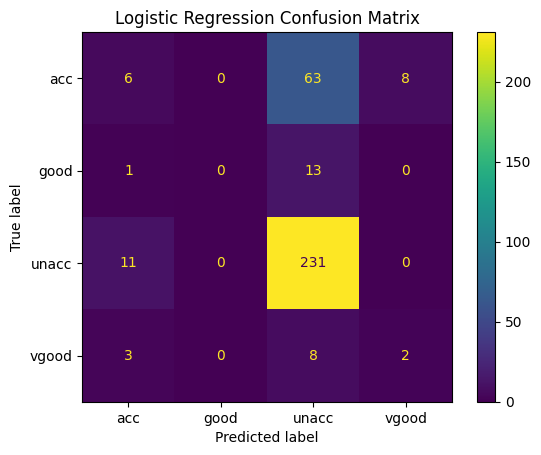

In [40]:

# ============================================================
# 10. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\n===== Confusion Matrix =====")
print(cm)


# Confusion Matrix 시각화
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_encoder.classes_
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()